# LLM JUDGE TEST

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from umap import UMAP
import seaborn as sns

#enable pandas tdqm
from tqdm import tqdm
tqdm.pandas()


In [93]:
%cd f:/robusto/vqa_analysis

f:\robusto\vqa_analysis


In [5]:
#load answers text cache
answers_text_cache_path = "./data/r2_cleaned.csv"
df_answers = pd.read_csv(answers_text_cache_path, keep_default_na=False) #keep_default_na=False to avoid converting empty strings to NaN
df_answers = df_answers[df_answers["REPETITION"] == 1].reset_index(drop=True)
df_answers["VIDEO_SECTOR"] = df_answers["VIDEO"].apply(lambda x: "LIMA" if int(x.split("_")[1]) <= 100 else "NYC")
print(f"Loaded answers text cache with {len(df_answers)} entries")
df_answers.head()

Loaded answers text cache with 10000 entries


,AGENT,VIDEO,BLOCK,QUESTION_NUM,REPETITION,ANSWER,VIDEO_SECTOR
0,human_lima_1,Robusto2_153,1,1,1,The ego vehicle is accelerating slowly because...,NYC
1,human_lima_2,Robusto2_153,1,1,1,The ego vehicle is turning to the right,NYC
2,human_lima_3,Robusto2_153,1,1,1,the ego vehicle brakes and steers slightly to ...,NYC
3,human_lima_4,Robusto2_153,1,1,1,Braking to yield,NYC
4,human_lima_5,Robusto2_153,1,1,1,The ego vehicle is moving forward while mainta...,NYC


In [6]:
KEYS = ["VIDEO", "QUESTION_NUM","VIDEO_SECTOR", "BLOCK", "AGENT","ANSWER"]
df_comp = pd.merge(df_answers[KEYS], df_answers[KEYS], on=["VIDEO", "QUESTION_NUM","VIDEO_SECTOR","BLOCK"], suffixes=('_I', '_J')) 
df_comp

,VIDEO,QUESTION_NUM,VIDEO_SECTOR,BLOCK,AGENT_I,ANSWER_I,AGENT_J,ANSWER_J
0,Robusto2_153,1,NYC,1,human_lima_1,The ego vehicle is accelerating slowly because...,human_lima_1,The ego vehicle is accelerating slowly because...
1,Robusto2_153,1,NYC,1,human_lima_1,The ego vehicle is accelerating slowly because...,human_lima_2,The ego vehicle is turning to the right
2,Robusto2_153,1,NYC,1,human_lima_1,The ego vehicle is accelerating slowly because...,human_lima_3,the ego vehicle brakes and steers slightly to ...
3,Robusto2_153,1,NYC,1,human_lima_1,The ego vehicle is accelerating slowly because...,human_lima_4,Braking to yield
4,Robusto2_153,1,NYC,1,human_lima_1,The ego vehicle is accelerating slowly because...,human_lima_5,The ego vehicle is moving forward while mainta...
...,...,...,...,...,...,...,...,...
249995,Robusto2_195,20,NYC,4,VideoLLaMA3-7B,The video does not provide any clear evidence ...,MiniCPM-o-2_6,"I'm sorry, but I cannot provide an analysis of..."
249996,Robusto2_195,20,NYC,4,VideoLLaMA3-7B,The video does not provide any clear evidence ...,Perception-LM-8B,"No, there is no vehicle or pedestrian in the s..."
249997,Robusto2_195,20,NYC,4,VideoLLaMA3-7B,The video does not provide any clear evidence ...,Phi-4-multimodal-instruct,"No, there are no visible signs of any vehicles..."
249998,Robusto2_195,20,NYC,4,VideoLLaMA3-7B,The video does not provide any clear evidence ...,Qwen3-VL-8B-Instruct,No vehicle or pedestrian is visibly violating ...


## JUDGER

In [ ]:
JUDGE_TEMPLATE = """
    You are a strict and impartial evaluator.

    Your task is to assess the semantic agreement between Response A and Response B 
    with respect to the given Question about an urban driving scene.

    Instructions:
    - Focus ONLY on factual and semantic content.
    - Ignore differences in writing style, tone, length, or level of detail.
    - Do not reward verbosity.
    - Do not assume unstated facts.
    - Do not explain anything beyond what is explicitly claimed in the output format.
    - Compare what is explicitly claimed in both responses.

    Agreement Scale:
    +2: Strong agreement — Both responses convey the same claims with no meaningful differences.
    +1: Partial agreement — The responses largely align but differ slightly in detail or emphasis.
    0: No clear relation — The responses address different aspects or do not meaningfully overlap.
    -1: Partial contradiction — The responses conflict on at least one important point.
    -2: Direct contradiction — The responses make opposing claims about the same fact.

    Output Format (JSON FILE format):
    {
        "Evaluation": <1 to 4 sentences justification>,
        "Score": <integer from -2 to 2>
    }
    
    Input: 
        Response A: {res_a}
        Response B: {res_b}

    Give your output as valid json FILE FORMAT.
"""

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

model_id = "Qwen/Qwen2.5-7B-Instruct"

# Configuración de "Emergencia" para 4GB de VRAM
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,              # Activa 4 bits
    bnb_4bit_quant_type="nf4",      # Formato de alta precisión
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True, # Compresión extra de los pesos
)

# Cargar Tokenizer y Modelo
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config, # Remove?
    device_map="auto",              
    low_cpu_mem_usage=True
)

# Get score using the model
def judge_row_answers(row):
    prompt = JUDGE_TEMPLATE.format(
        question=row['QUESTION'], 
        res_a=row['HUMAN_RESPONSE'], 
        res_b=row['VLM_RESPONSE']
    )
    
    # Formato de mensajes para Qwen
    messages = [
        {"role": "system", "content": "You are an impartial judge."},
        {"role": "user", "content": prompt}
    ]
    
    # Preparar el texto para el modelo
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    model_inputs = tokenizer([text], return_tensors="pt").to("cuda")

    # Generar respuesta
    generated_ids = model.generate(
        **model_inputs,
        max_new_tokens=150,
        temperature=0.1,    # Mantenerlo serio para el Score
        pad_token_id=tokenizer.eos_token_id
    )
    
    # Decodificar solo la respuesta nueva
    response = tokenizer.batch_decode(generated_ids[:, model_inputs.input_ids.shape[1]:], skip_special_tokens=True)[0]
    return response.strip()

In [ ]:
import json
def comparation_func(row):
    result_json = judge_row_answers(row)
    try:
        result = json.loads(result_json)
        agreement_score = result.get("Score", -1) # Default to 0 if not found
    except json.JSONDecodeError:
        agreement_score = -2 # If the LLM fails to return valid JSON, assume no agreement            
    return agreement_score
    
    #dummy comparator 

#prgoress apply using ofr loop for storage saving
checkpoint_path = "./llm_agreement_scores_qwen.parquet"
for idx, row in tqdm(df_comp.iterrows(), total=len(df_comp)):
    df_comp.at[idx, "SCORE"] = comparation_func(row)
    #save checkpoint every 100 rows
    if idx % 51200 == 0:
        df_comp.to_parquet(checkpoint_path)

df_comp

100%|████████████████████████████████████████████████████████████████████████| 250000/250000 [00:14<00:00, 17218.60it/s]


,VIDEO,QUESTION_NUM,VIDEO_SECTOR,BLOCK,AGENT_I,ANSWER_I,AGENT_J,ANSWER_J,SCORE
0,Robusto2_153,1,NYC,1,human_lima_1,The ego vehicle is accelerating slowly because...,human_lima_1,The ego vehicle is accelerating slowly because...,1.0
1,Robusto2_153,1,NYC,1,human_lima_1,The ego vehicle is accelerating slowly because...,human_lima_2,The ego vehicle is turning to the right,1.0
2,Robusto2_153,1,NYC,1,human_lima_1,The ego vehicle is accelerating slowly because...,human_lima_3,the ego vehicle brakes and steers slightly to ...,1.0
3,Robusto2_153,1,NYC,1,human_lima_1,The ego vehicle is accelerating slowly because...,human_lima_4,Braking to yield,1.0
4,Robusto2_153,1,NYC,1,human_lima_1,The ego vehicle is accelerating slowly because...,human_lima_5,The ego vehicle is moving forward while mainta...,1.0
...,...,...,...,...,...,...,...,...,...
249995,Robusto2_195,20,NYC,4,VideoLLaMA3-7B,The video does not provide any clear evidence ...,MiniCPM-o-2_6,"I'm sorry, but I cannot provide an analysis of...",1.0
249996,Robusto2_195,20,NYC,4,VideoLLaMA3-7B,The video does not provide any clear evidence ...,Perception-LM-8B,"No, there is no vehicle or pedestrian in the s...",1.0
249997,Robusto2_195,20,NYC,4,VideoLLaMA3-7B,The video does not provide any clear evidence ...,Phi-4-multimodal-instruct,"No, there are no visible signs of any vehicles...",1.0
249998,Robusto2_195,20,NYC,4,VideoLLaMA3-7B,The video does not provide any clear evidence ...,Qwen3-VL-8B-Instruct,No vehicle or pedestrian is visibly violating ...,1.0


In [12]:
#Now plot the df_comp
agg_df = (
    df_comp
    .groupby(
        ["VIDEO", "QUESTION_NUM","BLOCK","VIDEO_SECTOR", "AGENT_I", "AGENT_J"],
        as_index=False
    )["SCORE"]
    .mean()
)

agg_df2 = (
    agg_df
    .groupby(
        ["AGENT_I", "AGENT_J", "BLOCK","VIDEO_SECTOR"],
        as_index=False
    )["SCORE"]
    .mean()
)   
agg_df2

,AGENT_I,AGENT_J,BLOCK,VIDEO_SECTOR,SCORE
0,Cosmos-Reason2-8B,Cosmos-Reason2-8B,1,LIMA,1.0
1,Cosmos-Reason2-8B,Cosmos-Reason2-8B,1,NYC,1.0
2,Cosmos-Reason2-8B,Cosmos-Reason2-8B,2,LIMA,1.0
3,Cosmos-Reason2-8B,Cosmos-Reason2-8B,2,NYC,1.0
4,Cosmos-Reason2-8B,Cosmos-Reason2-8B,3,LIMA,1.0
...,...,...,...,...,...
4995,human_nyc_15,human_nyc_15,2,NYC,1.0
4996,human_nyc_15,human_nyc_15,3,LIMA,1.0
4997,human_nyc_15,human_nyc_15,3,NYC,1.0
4998,human_nyc_15,human_nyc_15,4,LIMA,1.0


In [16]:
def plot_judge(rsa_df, agents, title):
    nrows = 2
    ncols = 4
    fig, ax = plt.subplots(nrows, ncols, figsize=(7 * ncols, 5 * nrows),sharex=True,sharey=True)
    c = sns.diverging_palette(220, 20, as_cmap=True)

    for id_r, region in enumerate(df_answers["VIDEO_SECTOR"].unique()[::-1]):
        for block in df_answers["BLOCK"].astype(int).unique():
            c_ax = ax[id_r,block - 1]
            
            #select the data for the region and block
            df_block = rsa_df[(rsa_df["VIDEO_SECTOR"] == region) & (rsa_df["BLOCK"] == block)]
            rsa_matrix = df_block.pivot(index="AGENT_I", columns="AGENT_J", values="SCORE")
            
            #order columns and rows by agents order
            rsa_matrix = rsa_matrix.reindex(index=agents, columns=agents)
            sns.heatmap(rsa_matrix.to_numpy(), annot=False, xticklabels=rsa_matrix.columns, yticklabels=rsa_matrix.columns, cmap=c, ax=c_ax,square=True, vmin=-2, vmax=2,annot_kws={"fontsize":7})
            c_ax.set_title(f"Region: {region}, Block: {block}", fontsize=16, weight="bold")
            
    fig.suptitle(title, fontsize=24, weight="bold")
    out_name = title.replace(" ", "_").replace(":","-").lower()
    fig.tight_layout()
    fig.savefig(f"./judge_output_{out_name}.png", dpi=300)

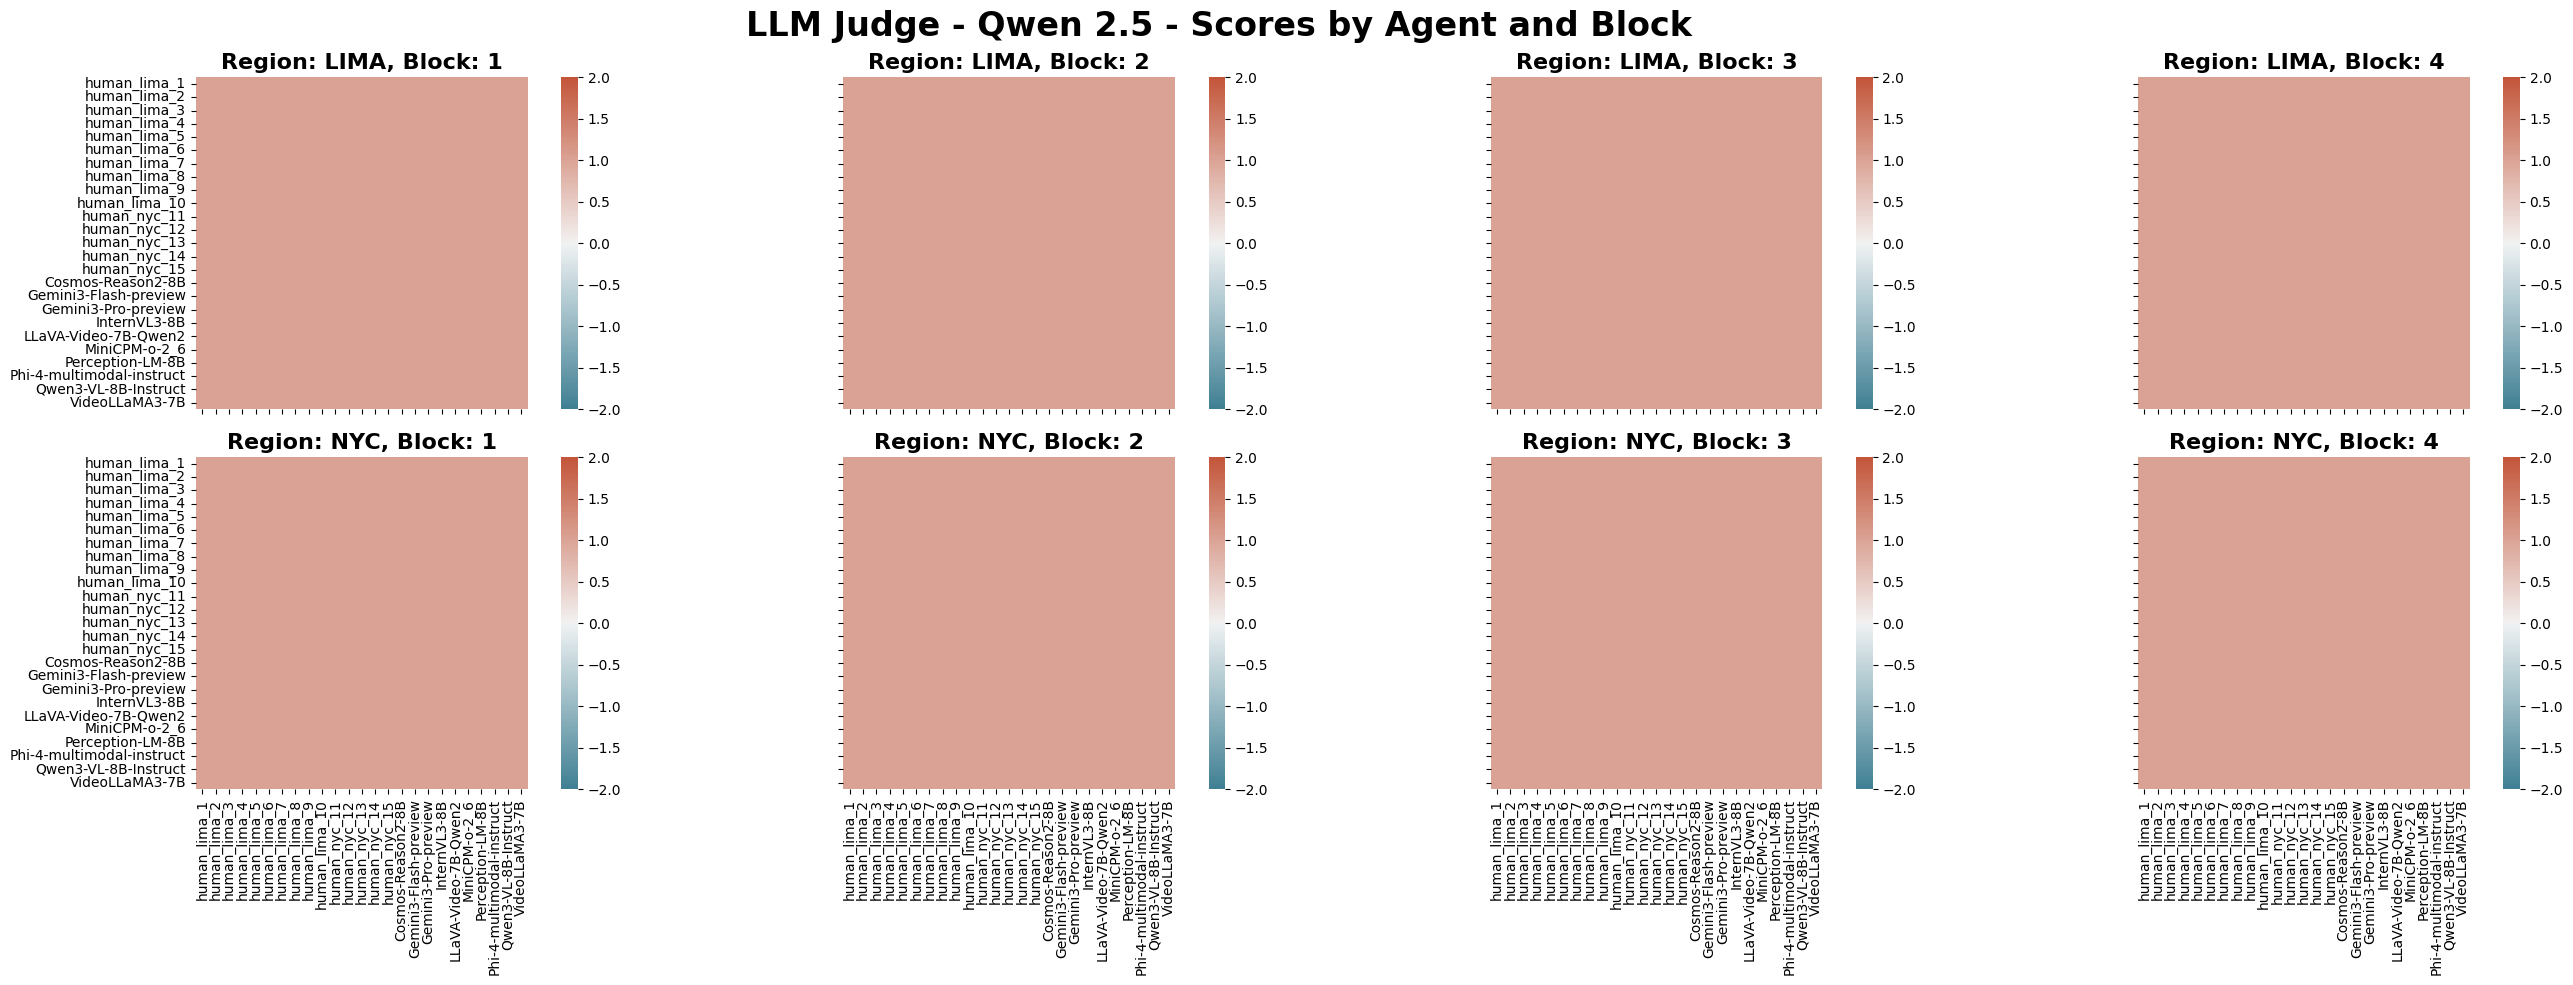

In [18]:
plot_judge(agg_df2, agents=df_answers["AGENT"].unique(), title="LLM Judge - Qwen 2.5 - Scores by Agent and Block")